## Import

In [1]:
import heapq
import time
from collections import deque

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display
from matplotlib.animation import FuncAnimation

try:
    import ipywidgets as widgets
    from ipywidgets import interact
    widgets_available = True
except ImportError:
    widgets_available = False

plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(24)
%matplotlib inline

print("Setup complete. Ready to explore BFS, DFS, and A* search.")

Setup complete. Ready to explore BFS, DFS, and A* search.


## Cell 2 — Maze Setup

,item,value
0,Rows,8
1,Columns,8
2,Open cells,35
3,Blocked cells,29
4,Start,"(0, 0)"
5,Goal,"(7, 7)"


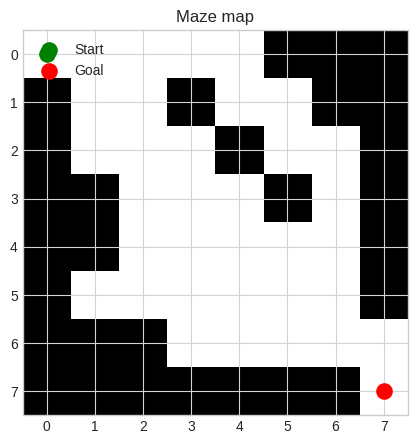

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Maze representation
# 0 = open cell, 1 = blocked cell

maze = np.array([
     [0, 0, 0, 0, 0, 1, 1, 1],
    [1, 0, 0, 1, 0, 0, 1, 1],
    [1, 0, 0, 0, 1, 0, 0, 1],
    [1, 1, 0, 0, 0, 1, 0, 1],
    [1, 1, 0, 0, 0, 0, 0, 1],
    [1, 0, 0, 0, 0, 0, 0, 1],
    [1, 1, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 1, 1, 1, 1, 0],
])

start = (0, 0)
goal = (7, 7)

maze_info = pd.DataFrame({
    "item": ["Rows", "Columns", "Open cells", "Blocked cells", "Start", "Goal"],
    "value": [
        maze.shape[0],
        maze.shape[1],
        int((maze == 0).sum()),
        int((maze == 1).sum()),
        str(start),
        str(goal),
    ],
})

display(maze_info)

plt.figure(figsize=(5, 5))
plt.imshow(maze, cmap="gray_r")
plt.scatter(start[1], start[0], color="green", s=120, label="Start")
plt.scatter(goal[1], goal[0], color="red", s=120, label="Goal")
plt.xticks(range(maze.shape[1]))
plt.yticks(range(maze.shape[0]))
plt.grid(color="lightgray")
plt.title("Maze map")
plt.legend(loc="upper left")
plt.show()

# Cell 3 — Helper Functions

In [3]:
# Helper functions used by all search algorithms

def in_bounds(position, grid):
    row, col = position
    return 0 <= row < grid.shape[0] and 0 <= col < grid.shape[1]


def is_open(position, grid):
    row, col = position
    return grid[row, col] == 0


def neighbors(position, grid):
    row, col = position
    candidates = [
        (row - 1, col),
        (row + 1, col),
        (row, col - 1),
        (row, col + 1),
    ]
    return [
        candidate
        for candidate in candidates
        if in_bounds(candidate, grid) and is_open(candidate, grid)
    ]


def reconstruct_path(parents, end_node):
    path = [end_node]
    while path[-1] in parents:
        path.append(parents[path[-1]])
    path.reverse()
    return path


def manhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


print("Helper functions are ready.")
print("Neighbors of start:", neighbors(start, maze))
print("Manhattan distance from start to goal:", manhattan(start, goal))

Helper functions are ready.
Neighbors of start: [(1, 0), (0, 1)]
Manhattan distance from start to goal: 14


## Cell 4 — BFS

In [4]:
def bfs(grid, start_node, goal_node):
    queue = deque([start_node])
    parents = {}
    visited = {start_node}
    expanded_order = []

    while queue:
        current = queue.popleft()
        expanded_order.append(current)

        if current == goal_node:
            return reconstruct_path(parents, current), expanded_order

        for neighbor in neighbors(current, grid):
            if neighbor not in visited:
                visited.add(neighbor)
                parents[neighbor] = current
                queue.append(neighbor)

    return None, expanded_order


print("BFS function created. It uses a queue and finds a shortest path.")

BFS function created. It uses a queue and finds a shortest path.


## Cell 5 — DFS

In [5]:
def dfs(grid, start_node, goal_node):
    stack = [start_node]
    parents = {}
    visited = {start_node}
    expanded_order = []

    while stack:
        current = stack.pop()
        expanded_order.append(current)

        if current == goal_node:
            return reconstruct_path(parents, current), expanded_order

        for neighbor in reversed(neighbors(current, grid)):
            if neighbor not in visited:
                visited.add(neighbor)
                parents[neighbor] = current
                stack.append(neighbor)

    return None, expanded_order


print("DFS function created. It uses a stack and may return a longer route.")

DFS function created. It uses a stack and may return a longer route.


## Cell 6 — A*

In [6]:
def a_star(grid, start_node, goal_node):
    open_heap = [(manhattan(start_node, goal_node), 0, start_node)]
    parents = {}
    g_score = {start_node: 0}
    closed = set()
    expanded_order = []

    while open_heap:
        _, current_cost, current = heapq.heappop(open_heap)

        if current in closed:
            continue

        closed.add(current)
        expanded_order.append(current)

        if current == goal_node:
            return reconstruct_path(parents, current), expanded_order

        for neighbor in neighbors(current, grid):
            new_cost = current_cost + 1

            if new_cost < g_score.get(neighbor, float("inf")):
                g_score[neighbor] = new_cost
                parents[neighbor] = current
                priority = new_cost + manhattan(neighbor, goal_node)
                heapq.heappush(open_heap, (priority, new_cost, neighbor))

    return None, expanded_order


print("A* function created. It uses Manhattan distance to guide the search.")

A* function created. It uses Manhattan distance to guide the search.


## Cell-7: Comparison in a separate cell

In [ ]:
# Comparison in a separate cell
results_df = pd.DataFrame([
    {
        "algorithm": result["algorithm"],
        "path_length": result["path_length"],
        "expanded_nodes": result["expanded_nodes"],
        "time_ms": result["time_ms"],
    }
    for result in results
])

display(results_df.round(4))

best_path = results_df.loc[results_df["path_length"].idxmin(), "algorithm"]
best_expansion = results_df.loc[results_df["expanded_nodes"].idxmin(), "algorithm"]

print("Shortest path found by:", best_path)
print("Fewest expanded nodes:", best_expansion)

results_df.plot(
    x="algorithm",
    y=["path_length", "expanded_nodes"],
    kind="bar",
    figsize=(7, 4),
    rot=0,
    title="Algorithm comparison",
)
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## Cell 8 — Run All Algorithms

In [7]:
# Run all algorithms

algorithms = {
    "BFS": bfs,
    "DFS": dfs,
    "A*": a_star,
}


def run_algorithm(name, algorithm):
    start_time = time.perf_counter()
    path, expanded_order = algorithm(maze, start, goal)
    elapsed = time.perf_counter() - start_time

    return {
        "algorithm": name,
        "path": path,
        "expanded_order": expanded_order,
        "path_length": len(path) - 1 if path else None,
        "expanded_nodes": len(expanded_order),
        "time_ms": elapsed * 1000,
    }


results = [run_algorithm(name, algorithm) for name, algorithm in algorithms.items()]

for result in results:
    print(
        f"{result['algorithm']}: path length = {result['path_length']}, "
        f"expanded nodes = {result['expanded_nodes']}"
    )

BFS: path length = 14, expanded nodes = 39
DFS: path length = 16, expanded nodes = 31
A*: path length = 14, expanded nodes = 26
